
--- Metrics ---
SP + Gaussian: MSE=37.57, PSNR=32.38
Gaussian + Median: MSE=46.65, PSNR=31.44
Blur + Median: MSE=22.32, PSNR=34.64


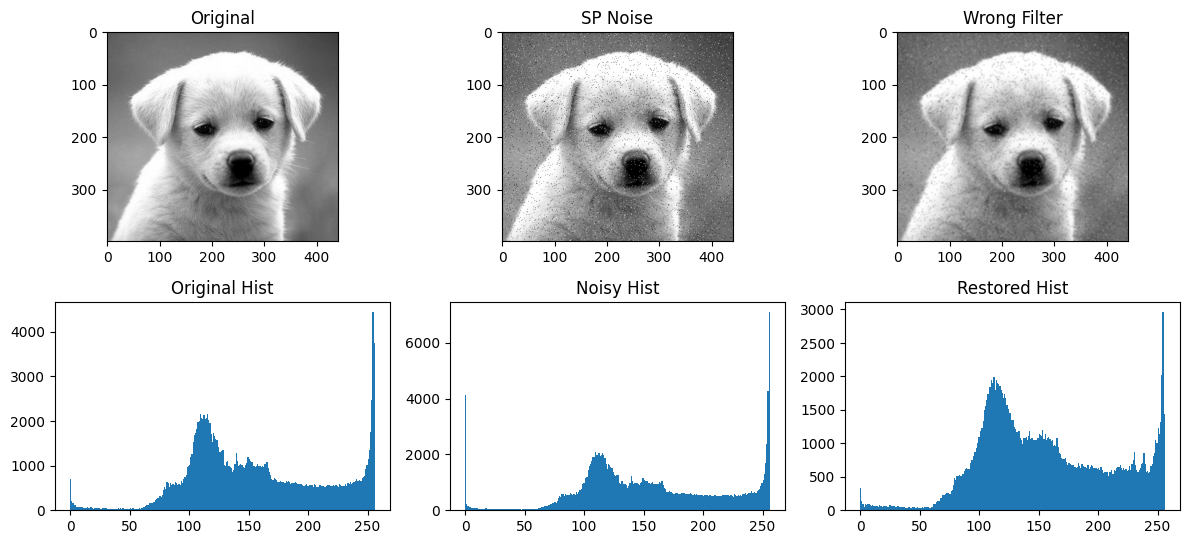

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mse(original, restored):
    return np.mean((original - restored) ** 2)

def psnr(original, restored):
    m = mse(original, restored)
    if m == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(m))

original = cv2.imread('/content/drive/MyDrive/Sample images/cutedog.jpg', 0)

if original is None:
    raise FileNotFoundError("Error: Could not load 'cutedog.jpg'. Please ensure the image file is in the correct directory.")


sp_noise = original.copy()
prob = 0.02
rnd = np.random.rand(*original.shape)
sp_noise[rnd < prob] = 0
sp_noise[rnd > 1 - prob] = 255

gaussian_noise = original + np.random.normal(0, 25, original.shape)
gaussian_noise = np.clip(gaussian_noise, 0, 255).astype(np.uint8)

blur_noise = cv2.GaussianBlur(original, (7,7), 0)

sp_wrong = cv2.GaussianBlur(sp_noise, (5,5), 0)

gaussian_wrong = cv2.medianBlur(gaussian_noise, 5)

blur_wrong = cv2.medianBlur(blur_noise, 5)

results = [
    ("SP + Gaussian", sp_wrong),
    ("Gaussian + Median", gaussian_wrong),
    ("Blur + Median", blur_wrong)
]

print("\n--- Metrics ---")
for name, img in results:
    m = mse(original, img)
    p = psnr(original, img)
    print(f"{name}: MSE={m:.2f}, PSNR={p:.2f}")

def plot_histogram(img, title):
    plt.hist(img.ravel(), bins=256, range=[0,256])
    plt.title(title)

plt.figure(figsize=(12,8))

plt.subplot(3,3,1)
plt.imshow(original, cmap='gray')
plt.title("Original")

plt.subplot(3,3,2)
plt.imshow(sp_noise, cmap='gray')
plt.title("SP Noise")

plt.subplot(3,3,3)
plt.imshow(sp_wrong, cmap='gray')
plt.title("Wrong Filter")

plt.subplot(3,3,4)
plot_histogram(original, "Original Hist")

plt.subplot(3,3,5)
plot_histogram(sp_noise, "Noisy Hist")

plt.subplot(3,3,6)
plot_histogram(sp_wrong, "Restored Hist")

plt.tight_layout()
plt.show()